[DIAG] ROI original: 2108×2176 pixels
[DIAG] Downscale: 775×800 (fator 0.37)
[DIVERGÊNCIA 31.0% → Enclosing]
Diâmetro estimado: 1967.16 px


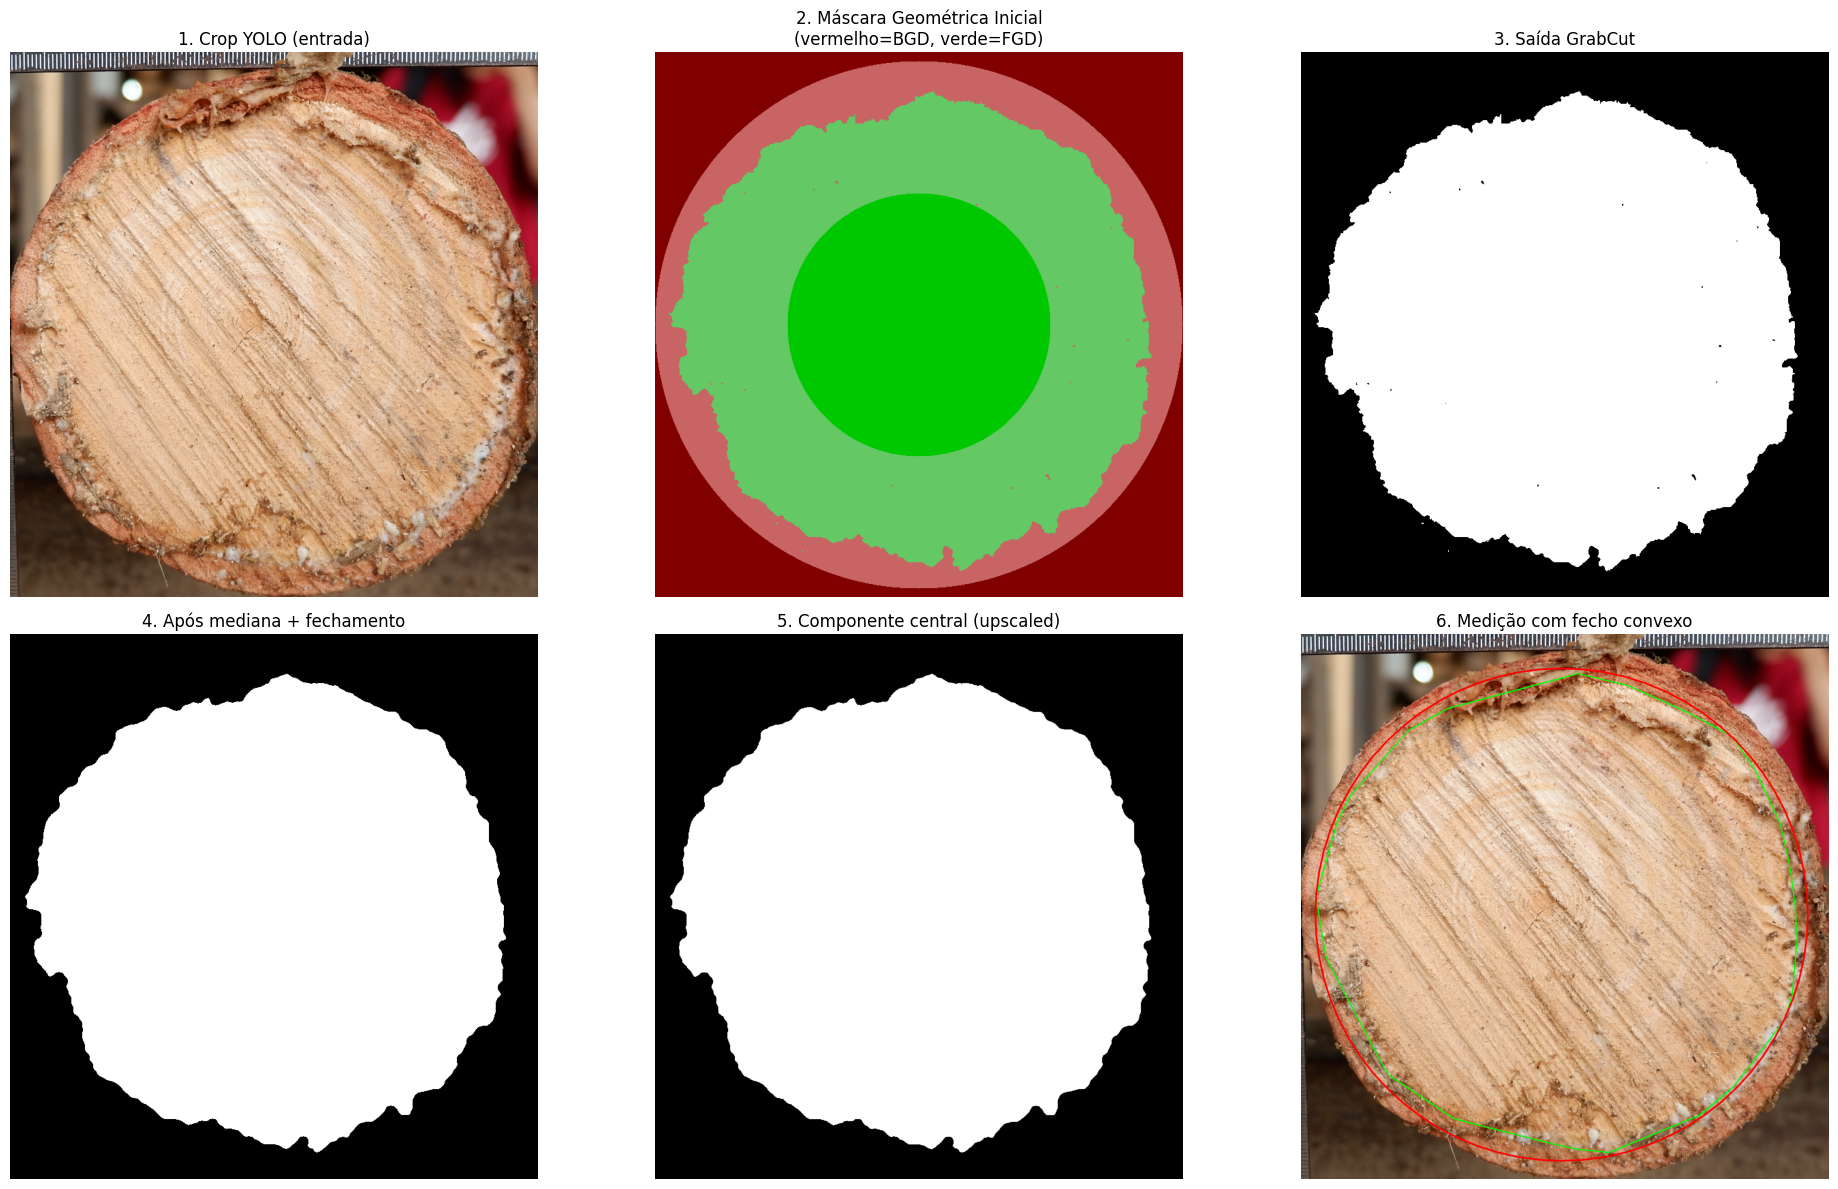

In [17]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

caminho_modelo = "../runs/detect/medicao_madeira_v2_fast/weights/best.pt"
model = YOLO(caminho_modelo)

caminho_imagens = glob.glob("../data/raw/train/images/*.jpg")
img_path = caminho_imagens[0]
img_bgr = cv2.imread(img_path)

# ============================================================
# FASE 1: INFERÊNCIA YOLO (na imagem CRUA, sem pré-processamento)
# ============================================================
# Removida a antiga Fase 1 (Bilateral + Open + Close pre-YOLO).
# YOLOv8 é treinada com data augmentation pesado e é robusta
# a ruído natural; suavização artificial só reduz entropia.
resultados = model(img_bgr, verbose=False)

crop_tronco = None
crop_medida = None

for box in resultados[0].boxes:
    cls_id = int(box.cls[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    if cls_id == 0:
        crop_tronco = img_bgr[y1:y2, x1:x2].copy()
    elif cls_id == 1:
        crop_medida = img_bgr[y1:y2, x1:x2].copy()

# ============================================================
# FASE 2 (V5): Pós-Processamento via GrabCut Geométrico
# ============================================================

if crop_tronco is not None:
    h_roi, w_roi = crop_tronco.shape[:2]
    print(f"[DIAG] ROI original: {w_roi}×{h_roi} pixels")

    # ---------- OTIMIZAÇÃO: Downscale para acelerar GrabCut ----------
    # GrabCut em ~2100×2100 leva ~60s na CPU. Reduzindo pra ~800px
    # no lado maior, o tempo cai pra ~8s sem perda perceptível
    # (a fronteira é dominada por estatísticas regionais de cor,
    # não por detalhes de alta frequência).
    ESCALA_MAX = 800
    fator = ESCALA_MAX / max(h_roi, w_roi)
    if fator < 1.0:
        h_s, w_s = int(h_roi * fator), int(w_roi * fator)
        crop_small = cv2.resize(crop_tronco, (w_s, h_s),
                                 interpolation=cv2.INTER_AREA)
        print(f"[DIAG] Downscale: {w_s}×{h_s} (fator {fator:.2f})")
    else:
        crop_small = crop_tronco
        h_s, w_s = h_roi, w_roi

    # ----- TÉCNICA 1: Filtro Bilateral -----
    # Reduz textura interna (ranhuras da serra) preservando a
    # fronteira tora-fundo. Aplicado em escala reduzida.
    crop_suave = cv2.bilateralFilter(crop_small, d=9,
                                      sigmaColor=75, sigmaSpace=75)

    # ----- TÉCNICA 2: Máscara Geométrica de Inicialização -----
    # Prior: "tora é circular e centralizada no crop do YOLO".
    #   Núcleo (r ≤ 25%):       FGD certo
    #   Anel médio (25–45%):    PR_FGD (provavelmente tora)
    #   Anel externo (45–50%):  PR_BGD (provavelmente fundo)
    #   Cantos (r > 50%):       BGD certo
    mask_gc = np.full((h_s, w_s), cv2.GC_BGD, dtype=np.uint8)
    centro = (w_s // 2, h_s // 2)
    lado_min = min(h_s, w_s)
    r_pequeno = int(lado_min * 0.25)
    r_medio   = int(lado_min * 0.45)
    r_grande  = int(lado_min * 0.50)

    cv2.circle(mask_gc, centro, r_grande,  cv2.GC_PR_BGD, -1)
    cv2.circle(mask_gc, centro, r_medio,   cv2.GC_PR_FGD, -1)
    cv2.circle(mask_gc, centro, r_pequeno, cv2.GC_FGD,    -1)

    # ----- TÉCNICA 3: GrabCut (Graph Cuts + GMM de cor) -----
    # Modela FG/BG como misturas gaussianas e resolve via
    # minimização de energia. Robusto contra sobreposição
    # cromática parcial graças à coerência espacial.
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    cv2.grabCut(crop_suave, mask_gc, None, bgdModel, fgdModel,
                iterCount=5, mode=cv2.GC_INIT_WITH_MASK)

    massa_grabcut = np.where((mask_gc == cv2.GC_FGD) |
                              (mask_gc == cv2.GC_PR_FGD),
                              255, 0).astype(np.uint8)

    # ----- TÉCNICA 4: Filtro de Mediana -----
    # Remove "dentes" de 1-2 pixels da fronteira do GrabCut
    # em regiões cromaticamente ambíguas.
    massa_suave = cv2.medianBlur(massa_grabcut, 7)

    # ----- TÉCNICA 5: Morfologia de Fechamento -----
    # Sela buracos internos residuais (ranhuras profundas
    # classificadas como background pelo GrabCut).
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    massa_fechada = cv2.morphologyEx(massa_suave, cv2.MORPH_CLOSE, kernel)

    # ----- TÉCNICA 6: Componente Conectado Central -----
    # Mantém apenas o blob mais próximo do centro com área
    # mínima de 5% da ROI (defesa contra fragmentos espúrios).
    num_labels, labels, stats, centroides = \
        cv2.connectedComponentsWithStats(massa_fechada, connectivity=8)

    massa_isolada = np.zeros_like(massa_fechada)
    if num_labels > 1:
        c = np.array([w_s / 2, h_s / 2])
        dist = np.linalg.norm(centroides[1:] - c, axis=1)
        areas = stats[1:, cv2.CC_STAT_AREA]
        dist[areas < 0.05 * h_s * w_s] = np.inf
        if not np.all(np.isinf(dist)):
            massa_isolada[labels == 1 + np.argmin(dist)] = 255

    # ---------- UPSCALE: máscara volta à resolução original ----------
    if fator < 1.0:
        massa_final = cv2.resize(massa_isolada, (w_roi, h_roi),
                                  interpolation=cv2.INTER_NEAREST)
        massa_final = cv2.morphologyEx(
            massa_final, cv2.MORPH_CLOSE,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    else:
        massa_final = massa_isolada

    # ----- TÉCNICA 7: Contornos + Fecho Convexo -----
    contornos, _ = cv2.findContours(massa_final, cv2.RETR_EXTERNAL,
                                     cv2.CHAIN_APPROX_SIMPLE)
    resultado_final = cv2.cvtColor(crop_tronco, cv2.COLOR_BGR2RGB).copy()

    if contornos:
        maior = max(contornos, key=cv2.contourArea)
        if cv2.contourArea(maior) < 0.05 * h_roi * w_roi:
            print("[ERRO] Contorno final muito pequeno. Segmentação falhou.")
        else:
            fecho = cv2.convexHull(maior)

            # ----- TÉCNICA 8: minEnclosingCircle -----
            (x_enc, y_enc), raio_enc = cv2.minEnclosingCircle(fecho)

            # ----- TÉCNICA 9: HoughCircles (validador cruzado) -----
            min_r = int(min(h_roi, w_roi) * 0.20)
            max_r = int(min(h_roi, w_roi) * 0.55)
            circulos = cv2.HoughCircles(
                massa_final, cv2.HOUGH_GRADIENT,
                dp=1.5, minDist=max(h_roi, w_roi),
                param1=50, param2=30,
                minRadius=min_r, maxRadius=max_r)

            if circulos is not None:
                x_h, y_h, raio_h = np.uint16(np.around(circulos))[0, 0]
                divergencia = abs(raio_h - raio_enc) / max(raio_enc, 1)
                if divergencia < 0.05:
                    raio_final = (raio_h + raio_enc) / 2
                    cx, cy = (x_h + x_enc) / 2, (y_h + y_enc) / 2
                    status = "CONSENSO Enclosing ≈ Hough"
                else:
                    raio_final, cx, cy = raio_enc, x_enc, y_enc
                    status = f"DIVERGÊNCIA {divergencia*100:.1f}% → Enclosing"
            else:
                raio_final, cx, cy = raio_enc, x_enc, y_enc
                status = "Hough não convergiu → Enclosing"

            cv2.drawContours(resultado_final, [fecho], -1, (0, 255, 0), 4)
            cv2.circle(resultado_final, (int(cx), int(cy)),
                       int(raio_final), (255, 0, 0), 5)
            print(f"[{status}]")
            print(f"Diâmetro estimado: {raio_final * 2:.2f} px")

    # ============================================================
    # DIAGNÓSTICO VISUAL (6 painéis)
    # ============================================================
    fig, ax = plt.subplots(2, 3, figsize=(20, 12))

    ax[0, 0].imshow(cv2.cvtColor(crop_tronco, cv2.COLOR_BGR2RGB))
    ax[0, 0].set_title("1. Crop YOLO (entrada)")

    # Visualização colorida da máscara de inicialização
    viz_init = np.zeros((h_s, w_s, 3), dtype=np.uint8)
    viz_init[mask_gc == cv2.GC_BGD]    = [128, 0, 0]
    viz_init[mask_gc == cv2.GC_PR_BGD] = [200, 100, 100]
    viz_init[mask_gc == cv2.GC_PR_FGD] = [100, 200, 100]
    viz_init[mask_gc == cv2.GC_FGD]    = [0, 200, 0]
    ax[0, 1].imshow(viz_init)
    ax[0, 1].set_title("2. Máscara Geométrica Inicial\n"
                       "(vermelho=BGD, verde=FGD)")

    ax[0, 2].imshow(massa_grabcut, cmap='gray')
    ax[0, 2].set_title("3. Saída GrabCut")

    ax[1, 0].imshow(massa_fechada, cmap='gray')
    ax[1, 0].set_title("4. Após mediana + fechamento")

    ax[1, 1].imshow(massa_final, cmap='gray')
    ax[1, 1].set_title("5. Componente central (upscaled)")

    ax[1, 2].imshow(resultado_final)
    ax[1, 2].set_title("6. Medição com fecho convexo")

    for a in ax.flat:
        a.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("O YOLO não conseguiu achar a madeira.")

In [18]:
print(f"Imagem original: {img_bgr.shape}")
print(f"Crop tronco:     {crop_tronco.shape}")
print(f"Bboxes detectadas:")
for box in resultados[0].boxes:
    cls_id = int(box.cls[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])
    print(f"  Classe {cls_id} | conf={conf:.2f} | "
          f"x=[{x1},{x2}] y=[{y1},{y2}] | "
          f"{(x2-x1)*(y2-y1)/(img_bgr.shape[0]*img_bgr.shape[1])*100:.1f}% da imagem")

Imagem original: (3264, 4896, 3)
Crop tronco:     (2176, 2108, 3)
Bboxes detectadas:
  Classe 0 | conf=0.99 | x=[1492,3600] y=[587,2763] | 28.7% da imagem
  Classe 1 | conf=0.97 | x=[1010,1473] y=[658,1180] | 1.5% da imagem
